# Decision Trees from Scratch — A Hands-On Tutorial

*Build a classifier that learns a flowchart of yes/no questions — using only NumPy — then read the exact rules it discovers.*

---

## Overview

This tutorial turns a compact `decision_tree.py` script into a complete, visual learning experience.

- **What it teaches:** how a **Decision Tree** splits data with a sequence of simple **yes/no questions**, how **entropy** and **information gain** pick the best question, and how tree **depth** trades underfitting for overfitting.
- **Who it's for:** beginners and intermediate learners who know a little Python and want to understand the intuition *and* the code behind the most interpretable model in machine learning.
- **ML task type:** **Classification** — predicting a *category / label*. (Trees handle **2 or more** classes natively.)

### Learning outcomes
By the end you will be able to:
1. Explain a decision tree as a **flowchart of questions** and how it carves feature space into **boxes**.
2. Define **entropy** (impurity) and **information gain**, and how the tree greedily picks each split.
3. Read a real **tree diagram** and the printed **if/else rules** the model learned.
4. Diagnose **overfitting** with a depth-complexity curve, and evaluate with **accuracy, precision, recall, F1**, a **confusion matrix**, and **ROC-AUC**.

### What you will build
A from-scratch `DecisionTree` class (no scikit-learn model) that mirrors the sklearn API — `fit` / `predict` / `predict_proba` — exposes `feature_importances_`, can **print its own rules** and be **drawn as a diagram**, plus charts including the **boxy non-linear boundary**, a **confusion matrix**, and **animations** of the tree carving the plane as it grows.

> **How to use this notebook (read me first)**
> - Run the cells **in order, top to bottom** — in VS Code click **▶▶ Run All**.
> - Every code cell is followed by a short **plain-English explanation**.
> - The **animations** have a ▶ play button — press it to watch the idea move.
> - Look for the **"Key insight"** lines: each is the single thing to remember from that chart.
> - Sections are numbered **1 → 16**; read the concept (1–2) first, then the code builds up step by step.


## 1. The concept in plain language

A **Decision Tree** classifies by playing **20 Questions**. Starting at the top (the *root*), it asks one simple question about a single feature — *"is petal length ≤ 2.5 cm?"* — and sends the point **left** (yes) or **right** (no). Each answer leads to another question until the point lands in a **leaf**, which votes for the **majority class** of the training examples that ended up there.

Because every question is about **one feature at a time** ("is $x_j \le t$?"), a tree slices the feature space into **axis-aligned boxes**, and predicts a constant class inside each box. Stacking many such cuts lets it draw **curved, non-linear** boundaries that a straight-line model (logistic regression, SVM, perceptron) simply cannot.

### How it decides which question to ask
At each node the tree tries **every feature and every threshold** and keeps the split that best **purifies** the two resulting groups. "Purity" is measured with **entropy**:

$$H(S) = -\sum_{c} p_c \log_2 p_c$$

where $p_c$ is the fraction of class $c$ in the group. Entropy is **0** for a perfectly pure group (all one class) and **maximal** for a 50/50 mix. The tree picks the split with the largest **information gain** — the drop in entropy from parent to children:

$$\text{IG} = H(\text{parent}) - \left(\frac{n_L}{n}H(\text{left}) + \frac{n_R}{n}H(\text{right})\right)$$

Then it repeats **recursively** on each child until the groups are pure or a stopping rule (max depth, min samples) kicks in.

### Everyday examples
Trees mirror how people already make decisions:

| Domain | Example questions asked | Predicted class (ŷ) |
|--------|-------------------------|----------------------|
| Banking | income? existing debt? job length? | approve vs decline loan |
| Medicine | temperature? blood test? age? | disease vs healthy |
| Botany | petal length? petal width? | iris species |
| Email | contains "free"? many links? | spam vs not-spam |
| Weather | humidity? windy? outlook? | play tennis vs stay in |
| HR | test score? experience? | hire vs pass |
| Retail | recency? spend? visits? | will churn vs stay |

### Two simple analogies
1. **A doctor's triage flowchart.** Each question narrows the diagnosis: *fever? → cough? → travel history?* Follow the branches and you reach a conclusion. A decision tree **learns** that flowchart automatically from data.
2. **Twenty Questions.** Each question should split the remaining possibilities as evenly and informatively as possible — that is exactly what **information gain** rewards.

### Why they're special
Unlike the linear models in the sibling notebooks, a tree needs **no feature scaling** (it only compares a feature to a threshold), handles **non-linear** patterns, mixes numeric and categorical logic, and — best of all — is **fully interpretable**: you can print the rules and show them to a domain expert.

### Key terms
- **Root / node / leaf** — the first question, an internal question, and a final prediction box.
- **Split** — a question "is feature $j \le t$?" dividing samples into left/right.
- **Entropy / Gini** — measures of impurity (how mixed a group's labels are).
- **Information gain** — the impurity drop a split achieves (bigger is better).
- **Depth** — how many questions deep the tree goes; the main **overfitting** knob.


### See it — why one straight line fails, but boxes win

Before any model code, here is the idea in one picture. The data below is the classic **XOR** pattern: class 1 in two *opposite* corners, class 0 in the other two. **No single straight line** can separate it — but two simple axis-aligned cuts (the questions a tree asks) split it into **four pure boxes**.

**Learning objective:** see how a tree stacks one-feature questions to carve non-linear regions that linear models can't. (Press ▶ to play.)


In [1]:
# Self-contained intuition demo (imports here so it runs even before Setup)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

rng = np.random.default_rng(0)
pts = rng.uniform(-3, 3, size=(200, 2))
# XOR labels: class 1 when the two features have the SAME sign
xor_y = ((pts[:, 0] > 0) == (pts[:, 1] > 0)).astype(int)

blue, red = "#2a72d4", "#e4572e"
fig, ax = plt.subplots(figsize=(6.5, 6.5))

def draw(frame):
    ax.clear()
    if frame >= 3:   # final frame: shade the four pure boxes
        for sx in (-1, 1):
            for sy in (-1, 1):
                cls = 1 if (sx > 0) == (sy > 0) else 0
                ax.add_patch(plt.Rectangle((0 if sx > 0 else -3, 0 if sy > 0 else -3),
                                           3, 3, color=(blue if cls else red), alpha=0.12))
    ax.scatter(pts[:, 0], pts[:, 1], c=[blue if v else red for v in xor_y],
               s=25, edgecolor="white", linewidth=0.3)
    if frame >= 1:   # split 1: vertical cut at feature_1 = 0
        ax.axvline(0, color="black", lw=2.5)
    if frame >= 2:   # split 2: horizontal cuts at feature_2 = 0
        ax.axhline(0, color="black", lw=2.5)
    titles = [
        "Raw XOR data — no single straight line can separate it",
        "Question 1: is feature_1 <= 0?  (one vertical cut)",
        "Question 2: is feature_2 <= 0?  (cut each side again)",
        "Four pure boxes -> a tree classifies XOR perfectly",
    ]
    ax.set_title(titles[min(frame, 3)])
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xlabel("feature_1"); ax.set_ylabel("feature_2")

intuition_anim = animation.FuncAnimation(fig, draw, frames=6, interval=1100)
plt.close(fig)  # avoid a duplicate static figure
HTML(intuition_anim.to_jshtml())


**What to notice:** a straight line is helpless on XOR, yet **two one-feature questions** cut the plane into four boxes, each **pure** (one colour). That is the whole trick of a decision tree: stack simple axis-aligned splits to build a boundary of any shape. Each cut is chosen to maximise **information gain** — the split that best separates the colours.


## 2. The machine-learning workflow

Almost every supervised-learning project follows the same path. Here is how this notebook maps onto it:

```mermaid
flowchart LR
    A[Load / generate data] --> B[Explore the data]
    B --> C[Train / test split]
    C --> D[Grow the tree - greedy splits]
    D --> E[Predict by traversing the tree]
    E --> F[Evaluate - accuracy, F1, ROC-AUC]
    F --> G[Visualise boundary, tree & rules]
    G --> H[Prune / tune depth]
```

| Step | What it means | Where in this notebook |
|------|---------------|------------------------|
| Data loading | Get labelled examples to learn from | Section 6 |
| Data exploration (EDA) | Look at shape, class balance, separation | Section 7 |
| Train/test split | Hold out data for honest evaluation | Section 6 |
| Model training | Greedily grow splits by information gain | Section 8 |
| Prediction | Walk a point down the tree to a leaf | Section 8 |
| Evaluation | accuracy, precision, recall, F1, ROC-AUC | Section 9 |
| Interpretation | Read the boundary, tree diagram, rules, importances | Sections 10–12 |

**Note on feature scaling:** decision trees are **scale-invariant** — a split only asks "is feature $j \le t$?", so multiplying a feature by 1000 just rescales the threshold and changes nothing. **No `StandardScaler` needed** (a nice contrast with the SVM/Perceptron notebooks). The knob that *does* matter is **`max_depth`**: too shallow underfits, too deep memorises noise (overfits).


## 3. Setup — import the tools

We use a small, standard stack:

- **NumPy** — the array math behind entropy, splits and traversal.
- **pandas** — to hold the data as a table for quick exploration.
- **Matplotlib / seaborn** — for the charts, the tree diagram, and animations.
- **scikit-learn** — *only* to generate/load datasets and split them. **The tree itself is written from scratch.**

> If a package is missing, install it once with:
> `pip install numpy pandas matplotlib seaborn scikit-learn plotly`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split

# Nicer default styling for all plots
sns.set_theme(style="whitegrid")
%matplotlib inline


## 4. Evaluation metrics (defined first so we can reuse them)

For **classification** we judge the model with a family of related numbers, all built from the **confusion matrix** $M$, where $M_{t,p}$ counts points with true class $t$ predicted as $p$.

$$\text{accuracy} = \frac{\text{correct}}{\text{total}} \qquad \text{precision}_c = \frac{TP_c}{TP_c+FP_c} \qquad \text{recall}_c = \frac{TP_c}{TP_c+FN_c}$$

$$F1_c = 2\cdot\frac{\text{precision}_c\cdot\text{recall}_c}{\text{precision}_c+\text{recall}_c}$$

- **Accuracy** — overall fraction correct (fair when classes are balanced).
- **Precision / Recall / F1** — computed **per class**, then **macro-averaged** so each class counts equally (essential for the 3-class dataset later).

> These work for **any number of classes**, with a tiny `eps` guarding the denominators.


In [3]:
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                     labels: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Build a confusion matrix ``M`` where ``M[t, p]`` counts true ``t`` predicted ``p``.

    Parameters
    ----------
    y_true, y_pred : array-like of shape (n_samples,)
        Ground-truth and predicted class labels.
    labels : np.ndarray, optional
        Ordered class labels; inferred from the data if not given.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The ``(k, k)`` count matrix and the array of labels (its row/col order).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    index = {label: i for i, label in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[index[t], index[p]] += 1
    return M, labels


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of predictions that exactly match the truth."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray,
                        labels: np.ndarray | None = None) -> tuple[float, float, float, pd.DataFrame]:
    """Macro-averaged precision, recall and F1, plus a per-class table.

    Returns
    -------
    tuple[float, float, float, pandas.DataFrame]
        ``(macro_precision, macro_recall, macro_f1, per_class_table)``.
    """
    M, labels = confusion_matrix(y_true, y_pred, labels)
    eps = 1e-12
    tp = np.diag(M).astype(float)
    fp = M.sum(axis=0) - tp
    fn = M.sum(axis=1) - tp
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    table = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                         index=[f"class {c}" for c in labels]).round(3)
    return float(precision.mean()), float(recall.mean()), float(f1.mean()), table


**What just happened:** three dependency-free helpers. `confusion_matrix` tallies every true/predicted pair; `accuracy` is the overall hit-rate; `precision_recall_f1` derives per-class scores plus their **macro averages** and a tidy table. We'll reuse them to score every tree in the notebook.


## 5. The model — Decision Tree from scratch

The model is two classes: a tiny **`Node`** (a question, or a leaf holding a prediction) and the **`DecisionTree`** that grows and traverses them. It mirrors scikit-learn's API:

- **`fit(X, y)`** — **recursively** grows the tree, at each node choosing the split with the highest **information gain**.
- **`predict(X)`** — walks each point down the questions to a leaf and returns its class.
- **`predict_proba(X)`** — returns the leaf's **class proportions** (used for ROC).

### Refactor notes (improvements over the original script)
- Kept the core algorithm: entropy, information gain, greedy best split, recursive growth, majority-vote leaves.
- Made it **deterministic** — the original used `np.random.choice` over features (random tie-breaks). We scan features in order (with an optional `random_state`+`n_feats` for random-forest-style subsampling), so results are reproducible.
- Split on **midpoints** between sorted unique values (cleaner thresholds) and support **`criterion="entropy"` or `"gini"`**.
- Added **`predict_proba`**, **`feature_importances_`** (normalised impurity decrease), **`export_text`** (print the rules) and a **`min_samples_split`/`max_depth`** guard.
- **`fit` returns `self`**; **`predict` validates** the tree was fitted. Type hints + NumPy-style docstrings throughout.


In [4]:
from collections import Counter


class Node:
    """A single node: an internal question, or a leaf holding a prediction.

    Internal nodes store ``feature`` and ``threshold`` (the test ``x[feature] <= threshold``)
    plus ``left``/``right`` children. Leaf nodes store a predicted ``value`` and the class
    ``proba`` distribution of the training samples that reached them.
    """

    def __init__(self, feature: int | None = None, threshold: float | None = None,
                 left: "Node | None" = None, right: "Node | None" = None,
                 *, value=None, proba: np.ndarray | None = None) -> None:
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.proba = proba

    def is_leaf(self) -> bool:
        """True if this node is a leaf (holds a prediction rather than a question)."""
        return self.value is not None


class DecisionTree:
    """A CART-style decision-tree classifier grown greedily by information gain.

    Parameters
    ----------
    max_depth : int, default 100
        Maximum number of question levels (the main overfitting control).
    min_samples_split : int, default 2
        A node with fewer samples than this becomes a leaf.
    criterion : {"entropy", "gini"}, default "entropy"
        Impurity measure used to score splits.
    n_feats : int, optional
        If set, only a random subset of this many features is considered per split
        (used by random forests); by default all features are considered.
    random_state : int, optional
        Seed for the optional feature subsampling.

    Attributes
    ----------
    classes_ : np.ndarray
        Sorted class labels, available after :meth:`fit`.
    feature_importances_ : np.ndarray
        Normalised total impurity decrease contributed by each feature.
    """

    def __init__(self, max_depth: int = 100, min_samples_split: int = 2,
                 criterion: str = "entropy", n_feats: int | None = None,
                 random_state: int | None = None) -> None:
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.n_feats = n_feats
        self.random_state = random_state
        self.root: Node | None = None
        self.classes_: np.ndarray | None = None
        self.feature_importances_: np.ndarray | None = None

    # --- impurity measures ---------------------------------------------------
    def _impurity(self, y: np.ndarray) -> float:
        """Entropy or Gini impurity of the label vector ``y``."""
        counts = np.bincount(y, minlength=len(self.classes_))
        p = counts[counts > 0] / len(y)
        if self.criterion == "gini":
            return float(1.0 - np.sum((counts / len(y)) ** 2))
        return float(-np.sum(p * np.log2(p)))          # entropy

    # --- training ------------------------------------------------------------
    def fit(self, X: np.ndarray, y: np.ndarray) -> "DecisionTree":
        """Grow the tree from training data ``X`` (features) and ``y`` (labels)."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        # map labels to 0..k-1 internally for fast counting
        self._class_index = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([self._class_index[v] for v in y])

        n_features = X.shape[1]
        self._n_feats = n_features if self.n_feats is None else min(self.n_feats, n_features)
        self._rng = np.random.default_rng(self.random_state)
        self._importances = np.zeros(n_features)

        self.root = self._grow(X, y_idx, depth=0)
        total = self._importances.sum()
        self.feature_importances_ = (self._importances / total) if total > 0 else self._importances
        return self

    def _grow(self, X: np.ndarray, y: np.ndarray, depth: int) -> Node:
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # stopping criteria -> make a leaf (majority class + class distribution)
        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            return self._leaf(y)

        feat_idxs = (np.sort(self._rng.choice(n_features, self._n_feats, replace=False))
                     if self._n_feats < n_features else np.arange(n_features))

        best_gain, best_feat, best_thresh = -1.0, None, None
        parent_impurity = self._impurity(y)
        for feat in feat_idxs:
            col = X[:, feat]
            uniq = np.unique(col)
            if len(uniq) < 2:
                continue
            thresholds = (uniq[:-1] + uniq[1:]) / 2.0       # midpoints
            for thr in thresholds:
                gain = self._information_gain(y, col, thr, parent_impurity)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thr

        if best_feat is None or best_gain <= 0:             # no useful split
            return self._leaf(y)

        # record this split's contribution to feature importance
        self._importances[best_feat] += best_gain * n_samples

        left_mask = X[:, best_feat] <= best_thresh
        left = self._grow(X[left_mask], y[left_mask], depth + 1)
        right = self._grow(X[~left_mask], y[~left_mask], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _information_gain(self, y: np.ndarray, col: np.ndarray, thr: float,
                          parent_impurity: float) -> float:
        left = y[col <= thr]
        right = y[col > thr]
        if len(left) == 0 or len(right) == 0:
            return 0.0
        n = len(y)
        child = (len(left) / n) * self._impurity(left) + (len(right) / n) * self._impurity(right)
        return parent_impurity - child

    def _leaf(self, y: np.ndarray) -> Node:
        counts = np.bincount(y, minlength=len(self.classes_))
        proba = counts / counts.sum()
        majority = int(np.argmax(counts))
        return Node(value=self.classes_[majority], proba=proba)

    # --- prediction ----------------------------------------------------------
    def _traverse(self, x: np.ndarray, node: Node) -> Node:
        if node.is_leaf():
            return node
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict a class label for each row of ``X`` by traversing the tree."""
        if self.root is None:
            raise RuntimeError("Model is not fitted yet — call fit() before predict().")
        X = np.asarray(X, dtype=float)
        return np.array([self._traverse(x, self.root).value for x in X])

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return each leaf's class-probability distribution for the rows of ``X``."""
        if self.root is None:
            raise RuntimeError("Model is not fitted yet — call fit() before predict_proba().")
        X = np.asarray(X, dtype=float)
        return np.array([self._traverse(x, self.root).proba for x in X])

    # --- interpretation ------------------------------------------------------
    def export_text(self, feature_names: list[str] | None = None,
                    class_names: list[str] | None = None) -> str:
        """Return the learned tree as human-readable indented if/else rules."""
        lines: list[str] = []

        def recurse(node: Node, depth: int) -> None:
            indent = "|   " * depth
            if node.is_leaf():
                name = class_names[self._class_index[node.value]] if class_names else node.value
                lines.append(f"{indent}|--- class: {name}")
                return
            fname = feature_names[node.feature] if feature_names else f"feature_{node.feature}"
            lines.append(f"{indent}|--- {fname} <= {node.threshold:.3f}")
            recurse(node.left, depth + 1)
            lines.append(f"{indent}|--- {fname} >  {node.threshold:.3f}")
            recurse(node.right, depth + 1)

        recurse(self.root, 0)
        return "\n".join(lines)


**What just happened:** we defined `Node` and `DecisionTree`. `fit` calls `_grow`, which — at each node — scans features and threshold midpoints, keeps the split with the largest **information gain**, and recurses until a group is pure or a stopping rule fires. Along the way it tallies each split's contribution to `feature_importances_`. Nothing about scale matters: splits only compare a feature to a threshold. Note the class definitions build the *blueprint*; the actual tree appears only after `fit`.


## 6. The data + train/test split

We start with **two interleaving moons** from `make_moons` — a deliberately **non-linear** pattern. Linear models (logistic regression, SVM, perceptron) struggle here, but a decision tree carves it up with a staircase of axis-aligned boxes.

- `n_samples=300` — 300 labelled points.
- `noise=0.25` — some overlap, so the task isn't trivial (and overfitting is possible).
- `random_state=42` — reproducible data.

We hold out **25%** as a **test set** to check generalization honestly.


In [5]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class balance (train):", np.bincount(y_train))


Train: (225, 2)  Test: (75, 2)
Class balance (train): [112 113]


**What just happened:** `make_moons` returned a `300 × 2` feature matrix `X` and 0/1 labels `y` arranged in two crescents. `train_test_split` shuffled and carved off 25% for testing; `stratify=y` keeps the class proportions identical in both splits.


## 7. Exploratory data analysis (EDA)

Before training we *look* at the data: its shape, whether values are missing or duplicated, the **class balance**, and the **shape** of the two classes — here a decidedly non-linear crescent pattern.


In [6]:
df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["label"] = y

print("Shape (rows, cols):", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Class counts:")
print(df["label"].value_counts())

display(df.head())
display(df.describe().round(3))


Shape (rows, cols): (300, 3)
Missing values: 0
Duplicate rows: 0
Class counts:
label
1    150
0    150
Name: count, dtype: int64


,feature_1,feature_2,label
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


,feature_1,feature_2,label
count,300.000,300.000,300.000
mean,0.502,0.266,0.500
std,0.910,0.553,0.501
min,-1.595,-1.045,0.000
25%,-0.086,-0.129,0.000
50%,0.499,0.274,0.500
75%,1.156,0.675,1.000
max,2.688,1.636,1.000


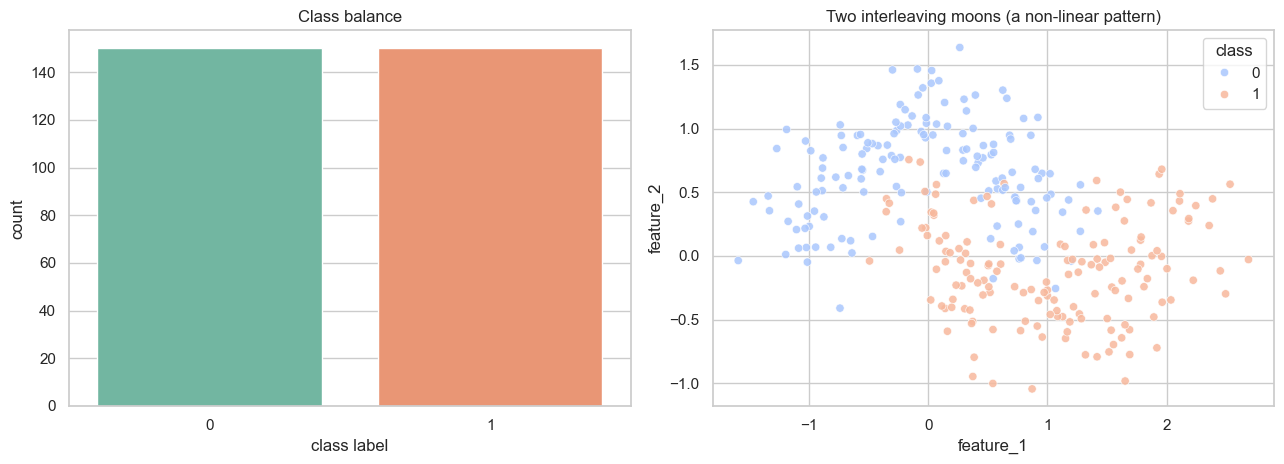

In [7]:
# Left: class balance.  Right: the two moons in feature space.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.countplot(x="label", data=df, ax=axes[0], hue="label", palette="Set2", legend=False)
axes[0].set_title("Class balance")
axes[0].set_xlabel("class label")
axes[0].set_ylabel("count")

sns.scatterplot(data=df, x="feature_1", y="feature_2", hue="label",
                palette="coolwarm", alpha=0.85, ax=axes[1])
axes[1].set_title("Two interleaving moons (a non-linear pattern)")
axes[1].legend(title="class")

plt.tight_layout()
plt.show()


**Key insight:** the two classes form **interlocking crescents** — no straight line separates them, which is exactly where a decision tree shines. The classes are balanced (left), so plain **accuracy** is a fair headline metric.

*Why seaborn here?* A class-count bar and a hue-coloured scatter are one line each. We keep Matplotlib for the custom boundary plots, the tree diagram, and animations later.


## 8. Train the model

We create the tree (capped at `max_depth=6` to keep it sensible), call `fit` on the **training data**, then `predict` on the **test data**. We also print the tree's **own rules** — the whole point of a decision tree is that you can *read* it.


In [8]:
tree = DecisionTree(max_depth=6, criterion="entropy").fit(X_train, y_train)

test_pred = tree.predict(X_test)
print("Classes:", tree.classes_)
print("Feature importances:", np.round(tree.feature_importances_, 3))
print("First 5 predicted:", test_pred[:5], " true:", y_test[:5])
print("\nA shallow view of the learned rules (depth-2 tree for readability):")
print(DecisionTree(max_depth=2).fit(X_train, y_train).export_text(
    feature_names=["feature_1", "feature_2"]))


Classes: [0 1]
Feature importances: [0.374 0.626]
First 5 predicted: [1 0 1 1 0]  true: [0 0 1 0 0]

A shallow view of the learned rules (depth-2 tree for readability):
|--- feature_2 <= 0.501
|   |--- feature_1 <= -0.497
|   |   |--- class: 0
|   |--- feature_1 >  -0.497
|   |   |--- class: 1
|--- feature_2 >  0.501
|   |--- feature_1 <= 1.346
|   |   |--- class: 0
|   |--- feature_1 >  1.346
|   |   |--- class: 1


**What just happened:** `fit` grew the tree by repeatedly choosing the highest-information-gain split. `predict` traversed each test point down to a leaf. The printed **rules** (shown for a shallow depth-2 tree so they fit on screen) are literally the model — a stack of `if feature <= threshold` questions ending in a class. That transparency is a decision tree's superpower.


## 9. Evaluate the model

**How to read these numbers:**
- **Accuracy** — overall fraction correct; fair here because the classes are balanced.
- **Precision / Recall / F1** — macro-averaged across classes.

A tree isn't trained by iteration, so it has **no loss curve**. The equivalent diagnostic is a **depth-complexity curve**: train and test accuracy as `max_depth` grows. It reveals the classic **underfit → sweet-spot → overfit** story.


In [9]:
acc = accuracy(y_test, test_pred)
prec, rec, f1, per_class = precision_recall_f1(y_test, test_pred)

print(f"Accuracy:        {acc:.3f}")
print(f"Macro precision: {prec:.3f}")
print(f"Macro recall:    {rec:.3f}")
print(f"Macro F1:        {f1:.3f}\n")
display(per_class)


Accuracy:        0.827
Macro precision: 0.829
Macro recall:    0.827
Macro F1:        0.827



,precision,recall,f1
class 0,0.857,0.789,0.822
class 1,0.800,0.865,0.831


### The depth-complexity curve — underfit vs overfit

We grow trees of increasing `max_depth` and track **train** vs **test** accuracy. A shallow tree underfits (both low); a very deep tree memorises the training noise (train ≈ 1.0, test drops). The best depth is where **test** accuracy peaks.


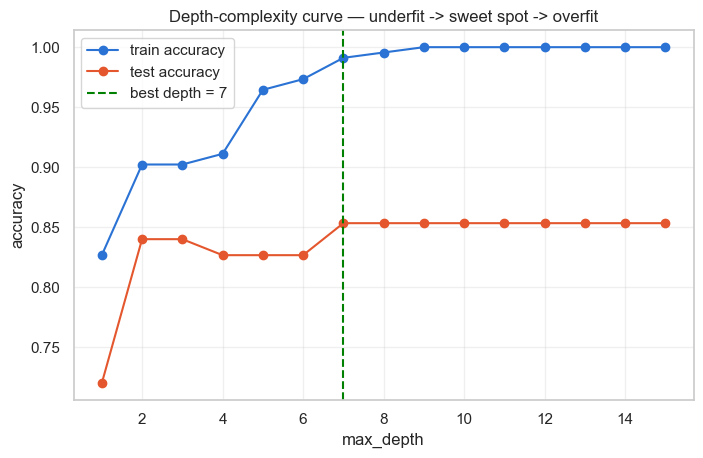

In [10]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTree(max_depth=d).fit(X_train, y_train)
    train_acc.append(accuracy(y_train, t.predict(X_train)))
    test_acc.append(accuracy(y_test, t.predict(X_test)))

best_d = list(depths)[int(np.argmax(test_acc))]
plt.figure(figsize=(8, 4.8))
plt.plot(list(depths), train_acc, "o-", label="train accuracy", color="#2a72d4")
plt.plot(list(depths), test_acc, "o-", label="test accuracy", color="#e4572e")
plt.axvline(best_d, color="green", ls="--", label=f"best depth = {best_d}")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Depth-complexity curve — underfit -> sweet spot -> overfit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Key insight:** the blue **train** curve keeps climbing toward 1.0 as the tree deepens — a deep tree can memorise every training point. But the red **test** curve rises, **peaks**, then **falls**: past the sweet spot (green line) the extra depth fits *noise*, not signal. Choosing `max_depth` near that peak is how you control overfitting — the tree equivalent of regularization.


## 10. Visualising results

Numbers tell us *how well*; charts tell us *how*. For a tree the standout views are the **boxy decision boundary**, the **tree diagram** itself, the **confusion matrix**, and the **ROC curve**.

### The decision boundary (boxes, not a line)
We colour the plane by the tree's prediction. Notice the **staircase** edges — every boundary segment is axis-aligned, the fingerprint of a decision tree.


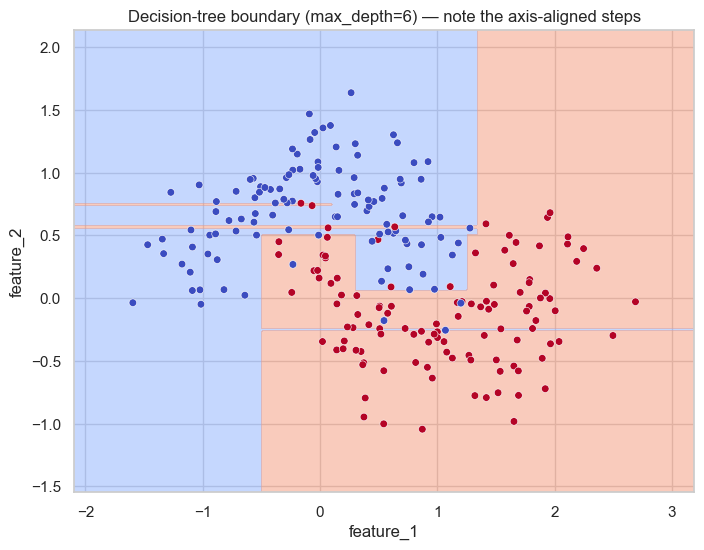

In [11]:
# Prediction map over the plane -> boxy boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
            edgecolor="white", s=30, linewidth=0.4)
plt.title(f"Decision-tree boundary (max_depth={tree.max_depth}) — note the axis-aligned steps")
plt.xlabel("feature_1"); plt.ylabel("feature_2")
plt.show()


**Key insight:** the boundary is a **staircase of rectangles**, not a smooth curve — because every split is "is one feature ≤ a threshold?". Stacking enough boxes approximates the curved moon shape. Too many boxes (deep tree) would trace every noisy point; the depth we chose keeps it smooth.

### The tree itself — a readable diagram
The best way to understand a tree is to *see* it. We draw a shallow tree (depth 3) as a flowchart: each box is a question; each leaf shows its majority class.


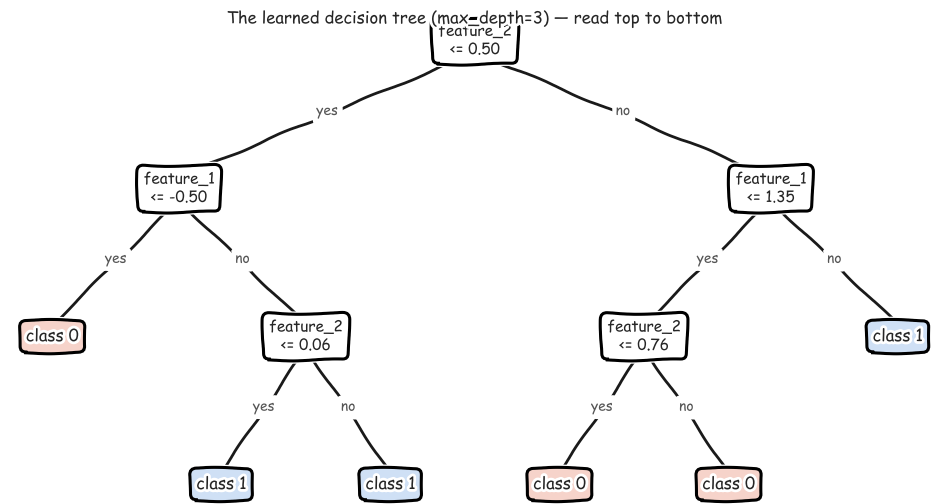

In [12]:
# Draw a shallow tree as a HAND-DRAWN (xkcd-style) node-link flowchart (depth 3)
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # hush font-fallback notices

small = DecisionTree(max_depth=3).fit(X_train, y_train)
feat_names = ["feature_1", "feature_2"]

def _layout(node, depth, x_counter, pos):
    if node.is_leaf():
        x = x_counter[0]; x_counter[0] += 1
        pos[id(node)] = (x, -depth); return x
    lx = _layout(node.left, depth + 1, x_counter, pos)
    rx = _layout(node.right, depth + 1, x_counter, pos)
    x = (lx + rx) / 2.0
    pos[id(node)] = (x, -depth); return x

positions = {}
_layout(small.root, 0, [0], positions)

# plt.xkcd() gives every line a wobbly, hand-sketched look (restored after the block)
with plt.xkcd(scale=1.0, length=100, randomness=2):
    fig, ax = plt.subplots(figsize=(12, 6))

    def _draw(node):
        x, yv = positions[id(node)]
        if node.is_leaf():
            cls = node.value
            ax.text(x, yv, f"class {cls}", ha="center", va="center", fontsize=12,
                    bbox=dict(boxstyle="round,pad=0.4", lw=2.2,
                              fc=("#cfe0f5" if cls == small.classes_[-1] else "#f6d3ca"),
                              ec="black"))
            return
        ax.text(x, yv, f"{feat_names[node.feature]}\n<= {node.threshold:.2f}",
                ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=2.2))
        for child, label in ((node.left, "yes"), (node.right, "no")):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [yv - 0.08, cy + 0.08], "k-", lw=2)
            ax.text((x + cx) / 2, (yv + cy) / 2, label, fontsize=10, color="#555",
                    ha="center", bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none"))
            _draw(child)

    _draw(small.root)
    ax.set_title("The learned decision tree (max_depth=3) — read top to bottom")
    ax.axis("off")
    plt.show()

**Key insight:** this **is** the model — no hidden weights, just questions. Start at the top, answer "yes" (≤ threshold) to go left or "no" to go right, and the leaf you reach is the prediction. You could hand this flowchart to a domain expert and they could apply it by hand. That interpretability is why trees are prized in medicine, finance, and any regulated field.

### Confusion matrix


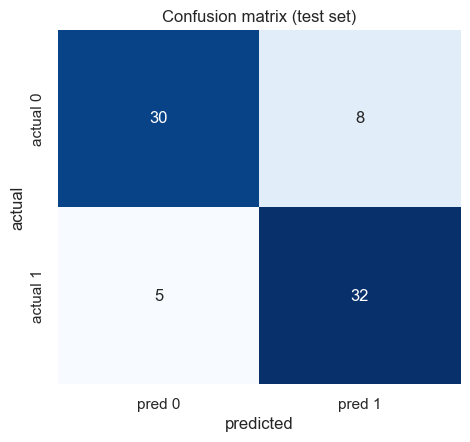

Rows = actual class, columns = predicted class


In [13]:
M, labels = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5.2, 4.6))
sns.heatmap(M, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"pred {c}" for c in labels],
            yticklabels=[f"actual {c}" for c in labels])
plt.title("Confusion matrix (test set)")
plt.ylabel("actual"); plt.xlabel("predicted")
plt.show()

print("Rows = actual class, columns = predicted class")


**Key insight:** the **diagonal** entries are correct predictions; **off-diagonal** are mistakes. A near-diagonal matrix means the boxy boundary captured the moons well.

### ROC curve
The **ROC curve** sweeps a threshold across the tree's predicted class-1 **probability** (leaf proportions) and plots the **true-positive rate** vs the **false-positive rate**. Its **area (AUC)** is a threshold-independent score.


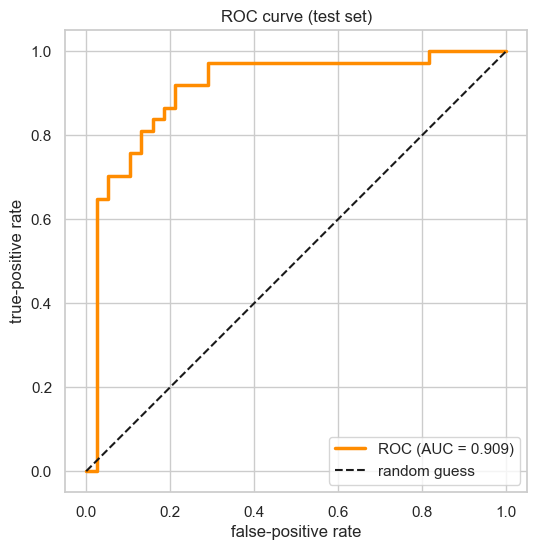

In [14]:
# ROC from the tree's predicted class-1 probability (leaf proportions)
proba1 = tree.predict_proba(X_test)[:, list(tree.classes_).index(1)]
order = np.argsort(-proba1)
y_sorted = y_test[order]

P = np.sum(y_test == 1)
N = np.sum(y_test == 0)
tpr = np.concatenate([[0], np.cumsum(y_sorted == 1) / P])
fpr = np.concatenate([[0], np.cumsum(y_sorted == 0) / N])
auc = float(np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="random guess")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("ROC curve (test set)")
plt.legend(loc="lower right"); plt.axis("square")
plt.show()


**Key insight:** the closer the orange curve hugs the **top-left corner**, the better. A tree's probabilities are **coarse** (they can only take the handful of values its leaves produce), so its ROC is a little **step-like** rather than smooth — a genuine, honest quirk of tree models.


## 11. Animation — the boundary grows with depth

A tree "learns" by getting **deeper**. We grow trees from depth 1 upward and redraw the boundary at each depth. Press ▶ to watch simple boxes refine into the moon shape — and keep an eye out for the moment extra depth starts chasing **noise**.


In [15]:
from matplotlib import animation
from IPython.display import HTML

depths_anim = list(range(1, 11))
grids = [DecisionTree(max_depth=d).fit(X_train, y_train)
         .predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) for d in depths_anim]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

def draw_depth(i):
    ax.clear()
    ax.contourf(xx, yy, grids[i], levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.5)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
               edgecolor="white", s=26, linewidth=0.3)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(f"max_depth = {depths_anim[i]}")
    ax.set_xlabel("feature_1"); ax.set_ylabel("feature_2")

depth_anim = animation.FuncAnimation(fig, draw_depth, frames=len(depths_anim), interval=650)
plt.close(fig)  # prevent a duplicate static figure
HTML(depth_anim.to_jshtml())


**What to notice:** at depth 1 the tree makes a single crude cut; each extra level adds boxes that hug the crescents better. But watch the deepest frames — tiny islands appear around individual points: that is **overfitting** starting, the visual twin of the falling test-accuracy tail in Section 9.


### Bonus: interactive extras (play and drag)

The animation above is a pre-rendered video. Here are two **interactive** Plotly views you can explore live.

> **Why no 3-D loss surface here?** The gradient-based notebooks (linear/logistic/SVM) show a ball rolling down a loss surface. A decision tree is **not** trained by gradient descent — it grows greedily — so a loss surface would be misleading. The right interactive story for a tree is **depth**: how the boundary and the train/test gap evolve as it grows.

#### 1. Boundary explorer — drag `max_depth`
Drag the slider (or press ▶) to watch the boxy boundary refine, then start fragmenting into overfit islands at high depth.


In [16]:
# Interactive boundary vs max_depth (Plotly heatmap frames + play + slider)
import plotly.graph_objects as go

gx = np.linspace(x_min, x_max, 120)
gy = np.linspace(y_min, y_max, 120)
GX, GY = np.meshgrid(gx, gy)
flat = np.c_[GX.ravel(), GY.ravel()]

depth_list = list(range(1, 11))
Zmaps = {d: DecisionTree(max_depth=d).fit(X_train, y_train).predict(flat).reshape(GX.shape)
         for d in depth_list}

def heat(d):
    return go.Heatmap(x=gx, y=gy, z=Zmaps[d], colorscale="RdBu", opacity=0.55,
                      showscale=False, zmin=0, zmax=1)

pts_layer = go.Scatter(x=X_train[:, 0], y=X_train[:, 1], mode="markers",
                       marker=dict(color=y_train, colorscale="RdBu", size=6,
                                   line=dict(color="white", width=0.5)), showlegend=False)

frames = [go.Frame(data=[heat(d), pts_layer], name=str(d)) for d in depth_list]
fig_b = go.Figure(data=[heat(depth_list[0]), pts_layer], frames=frames)
fig_b.update_layout(
    title=dict(text="Decision boundary vs max_depth  (watch overfitting appear)", x=0.5, xanchor="center"),
    xaxis_title="feature_1", yaxis_title="feature_2",
    template="plotly_white", width=760, height=560,
    updatemenus=[dict(type="buttons", x=0.0, y=1.15, showactive=False,
        buttons=[dict(label="Grow depth", method="animate",
                      args=[None, dict(frame=dict(duration=700, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="max_depth = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(d),
                    args=[[str(d)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for d in depth_list])],
)
fig_b.show()


**What to notice:** shallow depths give clean, smooth boxes; as you drag toward the deepest settings, small **islands** appear around individual points — the model memorising noise. The ideal depth is the smoothest boundary that still follows both crescents.

#### 2. Overfitting explorer — the train/test gap
This is the tree's version of a "hyperparameter that diverges": drag `max_depth` and watch **train accuracy** march to 1.0 while **test accuracy** peaks and then **degrades** — the widening gap *is* overfitting.


In [17]:
# Interactive overfitting explorer: train vs test accuracy with a moving depth marker
import plotly.graph_objects as go

d_axis = list(range(1, 16))
tr_acc = [accuracy(y_train, DecisionTree(max_depth=d).fit(X_train, y_train).predict(X_train)) for d in d_axis]
te_acc = [accuracy(y_test, DecisionTree(max_depth=d).fit(X_train, y_train).predict(X_test)) for d in d_axis]

base = [go.Scatter(x=d_axis, y=tr_acc, mode="lines+markers", name="train accuracy",
                   line=dict(color="#2a72d4")),
        go.Scatter(x=d_axis, y=te_acc, mode="lines+markers", name="test accuracy",
                   line=dict(color="#e4572e"))]

frames = [go.Frame(data=base + [go.Scatter(x=[d, d], y=[0, 1], mode="lines",
                                           line=dict(color="green", dash="dash"), showlegend=False)],
                   name=str(d)) for d in d_axis]

fig_o = go.Figure(data=base + [go.Scatter(x=[d_axis[0], d_axis[0]], y=[0, 1], mode="lines",
                                          line=dict(color="green", dash="dash"), showlegend=False)],
                  frames=frames)
fig_o.update_layout(
    title=dict(text="Overfitting explorer — train climbs, test peaks then degrades", x=0.5, xanchor="center"),
    xaxis_title="max_depth", yaxis_title="accuracy",
    template="plotly_white", width=760, height=470, yaxis=dict(range=[0.5, 1.02]),
    updatemenus=[dict(type="buttons", x=0.0, y=1.16, showactive=False,
        buttons=[dict(label="Sweep depth", method="animate",
                      args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="max_depth = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(d),
                    args=[[str(d)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for d in d_axis])],
)
fig_o.show()


**What to notice:** the **blue train** line keeps rising toward a perfect 1.0 — a deep tree can memorise everything. The **red test** line tells the truth: it peaks at a modest depth, then **degrades** as the tree overfits. That growing gap is the decision-tree analogue of a diverging model, and the reason we **limit depth** (or prune).

**More creative ideas you could add** (each just a few lines):
- an `ipywidgets` slider to drag a split threshold and watch information gain update;
- an **entropy-vs-Gini** toggle comparing the two impurity measures' boundaries;
- a **min_samples_leaf** explorer as an alternative overfitting control;
- a step-through **slideshow** of one split: compute entropy → try thresholds → pick max gain.

> **Note for GitHub:** these Plotly interactives render in VS Code/Jupyter but **not** in GitHub's static `.ipynb` preview. Re-run the notebook locally (or export static images) to see them.


## 12. Bonus example — a real, multi-class dataset (iris)

The moons were 2-D and binary. Let's point the **exact same from-scratch tree** at the most famous dataset in machine learning — **iris** — a real **multi-class** problem it handles with no code changes.

The **iris** dataset: **150 flowers**, **4 measurements** each (sepal length/width, petal length/width), and **3 species** (setosa, versicolor, virginica). Decision trees are the *classic* model for iris because the learned rules read like a botanist's key.

We'll walk the full workflow: **EDA → train → evaluate → interpret (rules + importances)**.


In [18]:
iris = load_iris()
Xi = iris.data                    # 150 x 4
yi = iris.target                  # 0,1,2
feat_names_i = list(iris.feature_names)
class_names_i = list(iris.target_names)

df_i = pd.DataFrame(Xi, columns=feat_names_i)
df_i["species"] = [class_names_i[c] for c in yi]

print("Shape (rows, cols):", df_i.shape)
print("Missing values:", df_i.isna().sum().sum())
print("Duplicate rows:", df_i.duplicated().sum())
print("Class counts:")
print(df_i["species"].value_counts())
display(df_i.head())


Shape (rows, cols): (150, 5)
Missing values: 0
Duplicate rows: 1
Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Exploratory data analysis

For a low-dimensional labelled dataset, a **class-coloured scatter** of the two most informative features (petal length vs petal width) shows how separable the species are.


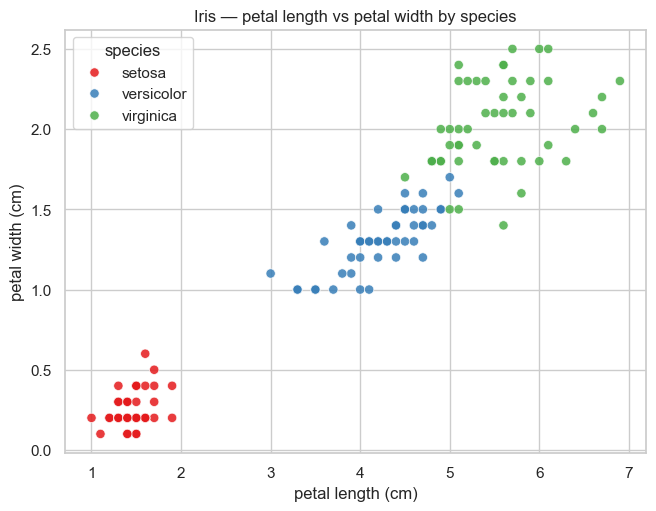

In [19]:
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=df_i, x="petal length (cm)", y="petal width (cm)",
                hue="species", palette="Set1", s=45, alpha=0.85)
plt.title("Iris — petal length vs petal width by species")
plt.legend(title="species")
plt.show()


**Key insight:** **setosa** (one cluster) is trivially separable by a single petal-length cut, while **versicolor** and **virginica** overlap a little — exactly the structure a tree exploits: one clean split isolates setosa, then finer petal-width splits tease apart the other two. Note we **don't scale** anything — the tree is scale-invariant.


In [20]:
# Split, then train the SAME tree (no scaling needed)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.25, random_state=1234, stratify=yi
)

tree_i = DecisionTree(max_depth=3, criterion="gini").fit(Xi_train, yi_train)
pred_i = tree_i.predict(Xi_test)

acc_i = accuracy(yi_test, pred_i)
prec_i, rec_i, f1_i, per_class_i = precision_recall_f1(yi_test, pred_i)
print(f"Accuracy:        {acc_i:.3f}")
print(f"Macro precision: {prec_i:.3f}")
print(f"Macro recall:    {rec_i:.3f}")
print(f"Macro F1:        {f1_i:.3f}\n")
display(per_class_i)


Accuracy:        0.947
Macro precision: 0.949
Macro recall:    0.949
Macro F1:        0.949



,precision,recall,f1
class 0,1.000,1.000,1.000
class 1,0.923,0.923,0.923
class 2,0.923,0.923,0.923


**What just happened:** the same class now handles **3 classes and 4 features** with zero changes (we switched to the `gini` criterion just to show it works — accuracy is near-identical to entropy). A shallow depth-3 tree is plenty for iris.


### The learned rules — a botanist's key

Because trees are interpretable, we can **print the exact rules** and read them like a field guide.


In [21]:
print(tree_i.export_text(feature_names=feat_names_i, class_names=class_names_i))


|--- petal length (cm) <= 2.350
|   |--- class: setosa
|--- petal length (cm) >  2.350
|   |--- petal length (cm) <= 4.750
|   |   |--- sepal length (cm) <= 4.950
|   |   |   |--- class: virginica
|   |   |--- sepal length (cm) >  4.950
|   |   |   |--- class: versicolor
|   |--- petal length (cm) >  4.750
|   |   |--- petal width (cm) <= 1.750
|   |   |   |--- class: versicolor
|   |   |--- petal width (cm) >  1.750
|   |   |   |--- class: virginica


**Key insight:** the rules read exactly like an identification key: a first cut on **petal length** peels off *setosa*, then **petal width** thresholds separate *versicolor* from *virginica*. No black box — you can verify each rule against botanical knowledge.


In [22]:
# Interactive multi-class confusion matrix (Plotly) with metrics annotated
import plotly.graph_objects as go

Mi, labels_i = confusion_matrix(yi_test, pred_i)
tick = [class_names_i[c] for c in labels_i]

fig_cm = go.Figure(go.Heatmap(
    z=Mi, x=[f"pred {n}" for n in tick], y=[f"actual {n}" for n in tick],
    colorscale="Blues", showscale=True, colorbar=dict(title="count"),
    text=Mi, texttemplate="%{text}", textfont=dict(size=15),
))
fig_cm.add_annotation(
    x=0.5, y=1.18, xref="paper", yref="paper", showarrow=False,
    text=f"Accuracy {acc_i:.3f}  -  Macro precision {prec_i:.3f}  -  "
         f"Macro recall {rec_i:.3f}  -  Macro F1 {f1_i:.3f}",
    font=dict(size=12, color="#444"),
)
fig_cm.update_layout(
    title=dict(text="Iris — confusion matrix (test set)", x=0.5, xanchor="center"),
    template="plotly_white", width=640, height=560, yaxis=dict(autorange="reversed"),
)
fig_cm.show()


**Key insight:** the matrix is almost purely **diagonal** — setosa is always right, and only the occasional versicolor/virginica pair is confused (the two overlapping clusters from the scatter). Any off-diagonal cell names exactly which species were mixed up.


In [23]:
# Feature importances — how much each measurement reduced impurity (Plotly bar)
import plotly.graph_objects as go

imp = pd.Series(tree_i.feature_importances_, index=feat_names_i).sort_values()

fig_imp = go.Figure()
fig_imp.add_bar(
    x=imp.values, y=list(imp.index), orientation="h",
    marker=dict(color="#4c9f70", line=dict(color="white", width=0.5)),
    text=[f"{v:.2f}" for v in imp.values], textposition="outside", cliponaxis=False,
    hovertemplate="%{y}: importance = %{x:.2f}<extra></extra>", showlegend=False,
)
fig_imp.update_layout(
    title=dict(text="Which measurements drive the tree?<br>"
                    "<sup>Iris — feature importance = normalised impurity decrease</sup>",
               x=0.5, xanchor="center"),
    xaxis_title="feature importance (sums to 1)", template="plotly_white",
    width=820, height=460, bargap=0.3, margin=dict(l=180, t=90, r=60, b=60),
)
fig_imp.show()


**Key insight:** **petal** measurements dominate the importance ranking, while sepal measurements barely matter — matching the scatter, where petal length/width alone separated the species. Feature importance here is simply *how much total impurity each feature removed* across all its splits, normalised to sum to 1 — a direct, honest read-out of what the tree relied on.


## 13. Key takeaways

- A decision tree is a **learned flowchart**: each node asks "is feature $j \le t$?" and each leaf votes the **majority class**.
- Splits are chosen greedily to **maximise information gain** (the drop in **entropy**/**Gini** impurity).
- Trees carve feature space into **axis-aligned boxes**, so they capture **non-linear** patterns straight lines can't — and need **no feature scaling**.
- **Depth** is the key knob: too shallow **underfits**, too deep **overfits** (train ≈ 1.0, test drops). Tune it with a depth-complexity curve.
- Trees are uniquely **interpretable** — you can print the rules and draw the diagram.
- **Real data is messier:** overlapping classes cap accuracy, and a single deep tree is high-variance — which motivates **ensembles** (random forests, boosting) as the next step.


## 14. Common mistakes and troubleshooting

| Problem | Cause | Fix |
|--------|-------|-----|
| Perfect train, poor test | Tree too deep → **overfitting** | Lower `max_depth`, raise `min_samples_split`, or prune |
| Both train & test poor | Tree too shallow → **underfitting** | Increase `max_depth` |
| Boundary looks jagged / islands | Fitting noise at high depth | Reduce depth; use an ensemble |
| Unstable — changes a lot per run | Trees are **high-variance** | Use a **random forest** (average many trees) |
| One class ignored | **Imbalanced** classes | Use class weights / resample; check **macro-F1** |
| Wasted effort scaling features | Trees are **scale-invariant** | Skip `StandardScaler` — it does nothing here |
| Coarse / step-like probabilities | Leaves emit only a few proportions | Expected; average trees (forest) for smoother scores |


## 15. Exercises

1. **Depth sweep.** Reproduce the depth-complexity curve on **iris**. Where is its sweet spot?
2. **Entropy vs Gini.** Fit both criteria on the moons; do the boundary and accuracy differ?
3. **Min samples.** Add a `min_samples_split` of 10 and 30 — how does the boundary smooth out?
4. **Read the rules.** Print the depth-3 moons tree with `export_text`; verify one path by hand on a test point.
5. **Feature importance.** Remove the least-important iris feature and retrain — does accuracy change?
6. **Compare.** Fit scikit-learn's `DecisionTreeClassifier` on both datasets and compare accuracy and the tree.
7. **Toward forests.** Train 20 trees on bootstrap samples with `n_feats=1` and average their `predict_proba` — does the test accuracy beat a single tree?


## 16. Next steps and improvements

- **Compare with scikit-learn's `DecisionTreeClassifier`** (and `plot_tree`) to sanity-check the from-scratch result.
- **Add pruning** (cost-complexity / minimal-leaf-size) to control overfitting more finely than a depth cap.
- **Ensemble the trees:** a **Random Forest** (bagging + feature subsampling) or **Gradient Boosting** dramatically improves accuracy and stability — the natural sequel to this notebook.
- **Support categorical splits** and missing values directly, as production tree libraries (XGBoost, LightGBM) do.
- **Regression trees:** swap entropy for variance reduction to predict numbers instead of classes.

---
*Built from the `decision_tree.py` "ML from scratch" implementation. The entropy / information-gain / recursive-greedy-growth logic is preserved; determinism, midpoint thresholds, a `gini` option, `predict_proba`, `feature_importances_`, `export_text`, type hints/docstrings, the tutorial structure, EDA, the tree diagram, evaluation visuals, animations, and the real multi-class walkthrough were added for self-study.*
